In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
%matplotlib inline

In [3]:
data = pd.read_csv('student_dropout_dataset_v3.csv')
data.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [4]:
data.drop(['Student_ID'], axis=1, inplace=True)

In [5]:
data.drop_duplicates(inplace=True)

In [6]:
data.dropna(inplace=True)

In [7]:
data.isnull().sum()

Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9020 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9020 non-null   float64
 1   Gender                 9020 non-null   object 
 2   Family_Income          9020 non-null   float64
 3   Internet_Access        9020 non-null   object 
 4   Study_Hours_per_Day    9020 non-null   float64
 5   Attendance_Rate        9020 non-null   float64
 6   Assignment_Delay_Days  9020 non-null   int64  
 7   Travel_Time_Minutes    9020 non-null   float64
 8   Part_Time_Job          9020 non-null   object 
 9   Scholarship            9020 non-null   object 
 10  Stress_Index           9020 non-null   float64
 11  GPA                    9020 non-null   float64
 12  Semester_GPA           9020 non-null   float64
 13  CGPA                   9020 non-null   float64
 14  Semester               9020 non-null   object 
 15  Departmen

## Finding columns which have high correlation with each other

In [9]:
data_corr = data.select_dtypes(include =['int64', 'float64'])


<Axes: >

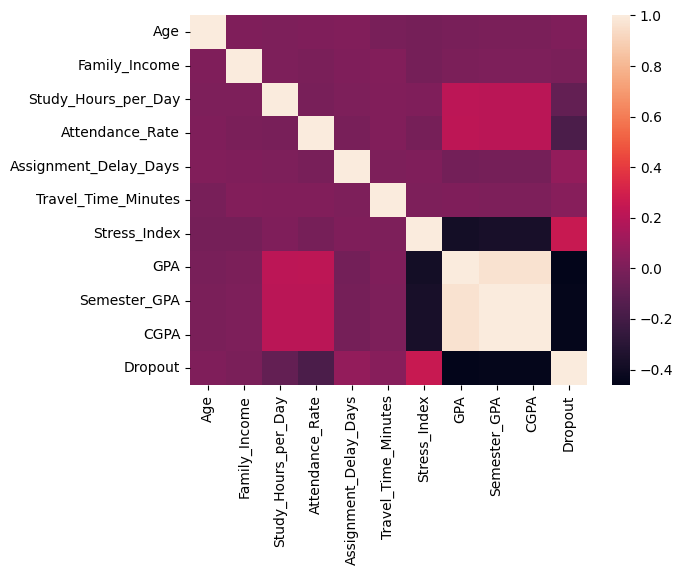

In [10]:
sns.heatmap(data_corr.corr()) 

In [11]:
# As we saw, there is high positive correlation between GPA, Semester_GPA, CGPA
data[['GPA', 'Semester_GPA', 'CGPA']].corr()

,GPA,Semester_GPA,CGPA
GPA,1.000000,0.964484,0.963663
Semester_GPA,0.964484,1.000000,0.999211
CGPA,0.963663,0.999211,1.000000


In [12]:
data.drop(['GPA', 'Semester_GPA'], axis=1, inplace=True) # we drop some columns in order to decrease the redundant information

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9020 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9020 non-null   float64
 1   Gender                 9020 non-null   object 
 2   Family_Income          9020 non-null   float64
 3   Internet_Access        9020 non-null   object 
 4   Study_Hours_per_Day    9020 non-null   float64
 5   Attendance_Rate        9020 non-null   float64
 6   Assignment_Delay_Days  9020 non-null   int64  
 7   Travel_Time_Minutes    9020 non-null   float64
 8   Part_Time_Job          9020 non-null   object 
 9   Scholarship            9020 non-null   object 
 10  Stress_Index           9020 non-null   float64
 11  CGPA                   9020 non-null   float64
 12  Semester               9020 non-null   object 
 13  Department             9020 non-null   object 
 14  Parental_Education     9020 non-null   object 
 15  Dropout  

In [14]:
data.Dropout = data.Dropout.astype('category', copy=False)

## Dividing dataset into target value and predictors

In [15]:
y = data['Dropout'] #our target value
X = data.drop(['Dropout'], axis=1) # our predictors

## Splitting dataset into training data and test data

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state=42)

In [17]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 1353 entries, 4150 to 7831
Series name: Dropout
Non-Null Count  Dtype   
--------------  -----   
1353 non-null   category
dtypes: category(1)
memory usage: 12.0 KB


In [18]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1353 entries, 4150 to 7831
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1353 non-null   float64
 1   Gender                 1353 non-null   object 
 2   Family_Income          1353 non-null   float64
 3   Internet_Access        1353 non-null   object 
 4   Study_Hours_per_Day    1353 non-null   float64
 5   Attendance_Rate        1353 non-null   float64
 6   Assignment_Delay_Days  1353 non-null   int64  
 7   Travel_Time_Minutes    1353 non-null   float64
 8   Part_Time_Job          1353 non-null   object 
 9   Scholarship            1353 non-null   object 
 10  Stress_Index           1353 non-null   float64
 11  CGPA                   1353 non-null   float64
 12  Semester               1353 non-null   object 
 13  Department             1353 non-null   object 
 14  Parental_Education     1353 non-null   object 
dtypes: flo

## Normilizing and Transforming model

In [19]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include = ['float64', 'int64']).columns.tolist()

In [20]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_features)
    ]
)

model = Pipeline(steps = [
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(
        class_weight = 'balanced',
        max_iter = 5000, 
        solver = 'saga'
    ))
])

## Training and cheking the quality of the model

In [21]:
model.fit(X_train, y_train)
y_predict = model.predict(X_test)

In [22]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1023
           1       0.47      0.72      0.57       330

    accuracy                           0.73      1353
   macro avg       0.68      0.73      0.69      1353
weighted avg       0.79      0.73      0.75      1353

